# Train an Ensemble of Last Layer Model for MNIST classification

In this notebook, we will train an MNIST convolutional classifier with a Bayesian last layer. First, we train a determinstic classifier to obtain a MAP estimate of the weights. Then, we replace the last layer of this model with an ensemble of deterministic last layers. We then train the ensemble using ensemble learning methods.

## Setup


In [22]:
inDrive = False

In [23]:
import sys
import os

if inDrive:
    from google.colab import drive
    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Hybrid-CLUE/MyImplementation/testing_notebooks')

# Get current directory and parent directory
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)

# Add parent directory to path if not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

Import libraries

In [24]:
import importlib
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os

import models.BLL
import models.mnist_classifier_BLL
import train
import sampler
import models.regene_models


Set the configuration

In [25]:
# 1. Configuration
class Config:
    # Data
    batch_size = 512

    # BLL training
    ensemble_ll_epochs = 10
    ensemble_ll_lr = 0.001
    ensemble_ll_patience = 10
    latent_dim = 256

    # Hardware
    device = 'cuda' if torch.cuda.is_available() \
    else 'mps' if torch.backends.mps.is_available() \
    else 'cpu'
    
    train = False

cfg = Config()

Load the Datasets

In [26]:
# Load the MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='../data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='../data', train=False, download=True, transform=transform)

# Split training set into train and validation
train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
trainset, valset = torch.utils.data.random_split(trainset, [train_size, val_size])

trainloader = torch.utils.data.DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True, num_workers=2)
valloader = torch.utils.data.DataLoader(valset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=cfg.batch_size, shuffle=False, num_workers=2)

Create a models and results directory if it doesn't exist

In [27]:
models_dir = '../model_saves/new_regene_models'
results_dir = '../results/new_regene_models'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

## Backbone
We'll start with the backbone loading. Options are either classifier_dominated, joint_training, or autoencoder_dominated.

In [28]:
classifier_dominated = False
joint_training = True
autoencoder_dominated = False

### Load chosen model

Load model

In [29]:
importlib.reload(models.regene_models)

decoder = models.regene_models.Decoder(latent_dim=cfg.latent_dim, device=cfg.device)
backbone = models.regene_models.Classifier(latent_dim=cfg.latent_dim, num_classes=10, device=cfg.device)

if classifier_dominated:
    backbone.load(models_dir + '/classifier_dominated_classifier_256.pt')
    decoder.load(models_dir + '/classifier_dominated_decoder_256.pt')
    name = 'classifier_dominated'
elif joint_training:
    backbone.load(os.path.join(models_dir, 'joint_classifier_256.pt'))
    decoder.load(os.path.join(models_dir, 'joint_decoder_256.pt'))
    name = 'joint_training'
elif autoencoder_dominated:
    backbone.load(models_dir + '/autoencoder_dominated_classifier_full_256.pt')
    decoder.load(models_dir + '/autoencoder_dominated_decoder_256.pt')
    name = 'autoencoder_dominated'

Loaded classifier model from: ../model_saves/new_regene_models/joint_classifier_256.pt
Loaded decoder model from: ../model_saves/new_regene_models/joint_decoder_256.pt


## Ensemble Last Layer
Next we'll train an ensemble of last layers.


### Load the model

In [30]:
from models.ensemble_LL import EnsembleLastLayer

import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

ensemble_model = EnsembleLastLayer(
    backbone=backbone,
    input_dim=cfg.latent_dim,  # Matches backbone's encoder output
    output_dim=10,  # MNIST classes
    n_members=50,
    device=cfg.device
)

# Verify all model components are on the correct device
print(f"Backbone device: {next(ensemble_model.backbone.parameters()).device}")
print(f"Last layer device: {next(ensemble_model.ensemble.parameters()).device}")

Backbone device: mps:0
Last layer device: mps:0


### Train the model

In [31]:
if cfg.train:   
    ensemble_model.train_ensemble(
        train_loader=trainloader,
        val_loader=valloader,
    epochs=cfg.ensemble_ll_epochs,        # Epochs per member
    lr=cfg.ensemble_ll_lr,
    bootstrap=True   # Use bootstrapping for diversity
    ensemble_model.save_checkpoint(models_dir + '/ensemble_model.pt')
)

### Load the model

In [32]:
ensemble_model.load_checkpoint(models_dir + '/ensemble_model.pt')

 [load_checkpoint] Loaded checkpoint from ../model_saves/new_regene_models/ensemble_model.pt


### Test the model
To check for Bayesian behaviour, we find an uncertain prediction and visualize multiple samples from the posterior.


In [39]:
def find_uncertain_examples(ensemble_model, data_loader, device='mps', top_k=10):
    """
    Find the most uncertain examples from a batch of data.
    
    Args:
        ensemble_model: Your trained ensemble model
        data_loader: DataLoader with examples to examine
        device: Device to run the model on
        top_k: Number of most uncertain examples to return
        
    Returns:
        images: Batch of images
        labels: Batch of labels
        uncertain_indices: Indices of the top_k most uncertain examples (sorted by uncertainty)
        prob_stack: Probability predictions from all ensemble members
    """
    import torch
    
    # Get a batch of data
    images, labels = next(iter(data_loader))
    images, labels = images.to(device), labels.to(device)
    
    # Get predictions from all ensemble members
    with torch.no_grad():
        prob_stack = ensemble_model.sample_predict(images)  # [n_members, batch_size, n_classes]
    
    # Calculate variance to find uncertain examples
    prob_variance = prob_stack.var(dim=0).sum(dim=1)  # [batch_size]
    
    # Find the top_k most uncertain examples
    top_k = min(top_k, len(prob_variance))  # Make sure we don't request more than batch size
    _, uncertain_indices = torch.topk(prob_variance, top_k)
    uncertain_indices = uncertain_indices.cpu().tolist()  # Convert to list for easier handling
    
    return images, labels, uncertain_indices, prob_stack

def visualize_ensemble_prediction(ensemble_model, x_uncertain, y_uncertain, prob_stack, uncertain_idx, num_samples=10):
    """
    Visualize probability distributions from multiple ensemble members for an uncertain example.
    
    Args:
        ensemble_model: Your trained ensemble model
        x_uncertain: The uncertain image to visualize
        y_uncertain: The true label of the uncertain image
        prob_stack: Probability predictions from all ensemble members
        uncertain_idx: Index of the uncertain example
        num_samples: Number of ensemble members to visualize
    
    Returns:
        x_uncertain: The uncertain image
        y_uncertain: The true label
        probs: Probability predictions for the uncertain example
    """
    import matplotlib.pyplot as plt
    import torch
    
    # Get prediction samples for this example (use up to num_samples ensemble members)
    num_samples = min(num_samples, prob_stack.shape[0])
    probs = prob_stack[:num_samples, uncertain_idx]  # [num_samples, n_classes]
    
    # ---- Visualization ----
    # 1. Show the image
    plt.figure(figsize=(5, 5))
    img = x_uncertain.squeeze().cpu()
    if img.shape[0] == 1:  # If grayscale, remove channel dimension
        img = img.squeeze(0)
    plt.imshow(img, cmap='gray' if len(img.shape) == 2 else None)
    plt.axis('off')
    plt.title(f'Uncertain Image (True Class: {y_uncertain})')
    plt.show()
    
    # 2. Plot the softmax distributions
    plt.figure(figsize=(10, 6))
    x_axis = range(probs.shape[1])  # Range over number of classes

    for i in range(num_samples):
        plt.plot(x_axis, probs[i].cpu().numpy(), 'o-', alpha=0.7, label=f'Member {i+1}')

    plt.xlabel('Class')
    plt.ylabel('Probability')
    plt.title(f'Ensemble Model: Softmax Distribution Samples\nTrue Class: {y_uncertain}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return x_uncertain, y_uncertain, probs

In [40]:
# Usage example:
images, labels, uncertain_indices, prob_stack = find_uncertain_examples(
    ensemble_model=ensemble_model,
    data_loader=testloader,
    device=cfg.device,
    top_k=5  # Get top 5 most uncertain examples
)

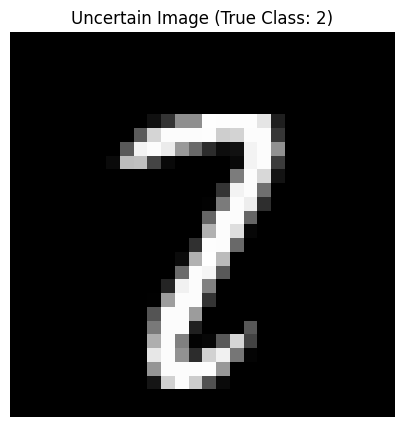

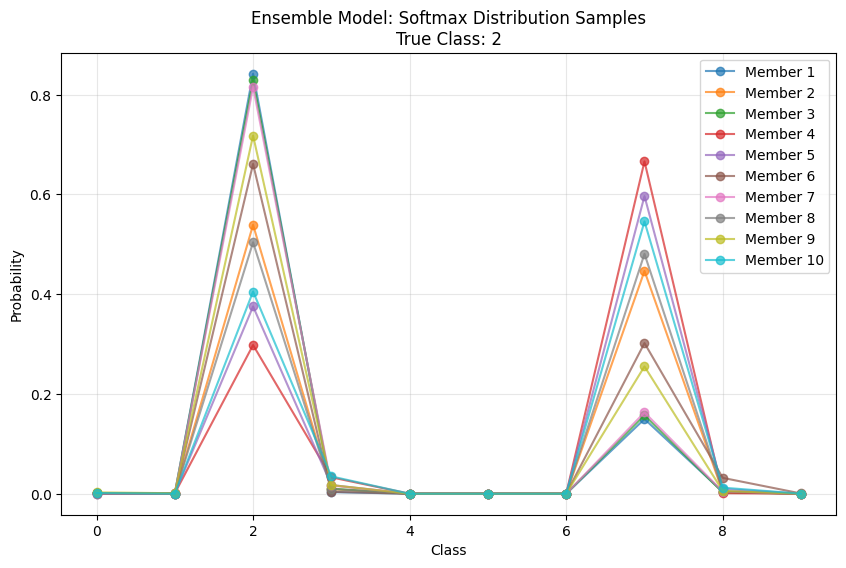

In [42]:
# Select the most uncertain example (first in the list)
uncertain_idx = uncertain_indices[2]
x_uncertain = images[uncertain_idx]
y_uncertain = labels[uncertain_idx].item()

x_uncertain, y_uncertain, probs = visualize_ensemble_prediction(
    ensemble_model=ensemble_model,
    x_uncertain=x_uncertain,
    y_uncertain=y_uncertain,
    prob_stack=prob_stack,
    uncertain_idx=uncertain_idx,
    num_samples=10
)

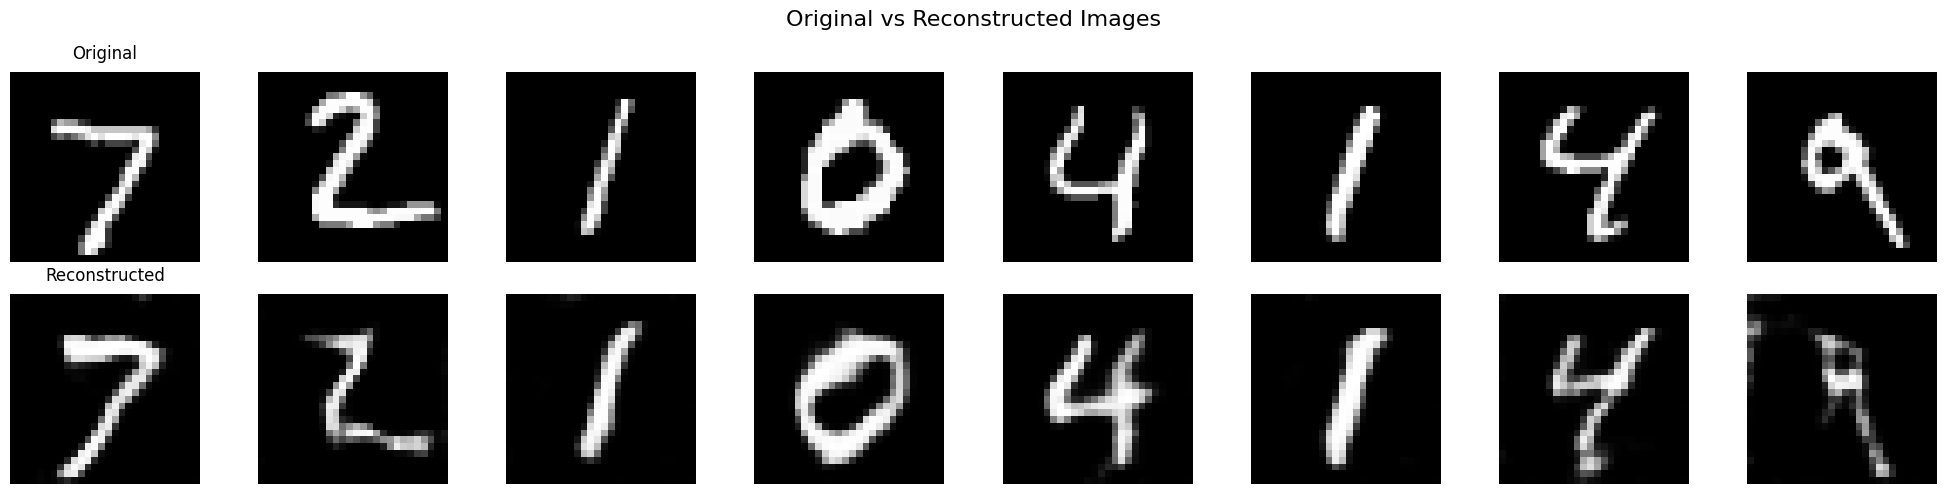

Reconstruction MSE: 0.0526


In [13]:
# Get test images
test_images, test_labels = next(iter(testloader))
test_images = test_images.to(cfg.device)

# Get reconstructions using the classifier and decoder
with torch.no_grad():
    # Get latent representations from classifier
    latent_reps, _ = backbone(test_images)  # Returns (latent_rep, logits)
    # Reconstruct using decoder
    reconstructions = decoder(latent_reps)

# Plot original and reconstructed images
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Original vs Reconstructed Images', fontsize=16)

# Plot original images
for i in range(8):
    axes[0,i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0,i].axis('off')
    if i == 0:
        axes[0,i].set_title('Original', pad=10)

# Plot reconstructions
for i in range(8):
    axes[1,i].imshow(reconstructions[i].cpu().squeeze(), cmap='gray')
    axes[1,i].axis('off')
    if i == 0:
        axes[1,i].set_title('Reconstructed', pad=10)

plt.tight_layout()
plt.show()

# Optionally, calculate reconstruction error
mse = nn.MSELoss()
recon_error = mse(reconstructions, test_images)
print(f'Reconstruction MSE: {recon_error.item():.4f}')